In [37]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

data = spark.read.parquet("training_data/combined_yellow_fhvhv.parquet")
print(data.count())
data.show(20)

330980
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+
|      date|PULocationID|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+
|2023-01-01|           7|1685.8999999999999| 7.430647803966266|                   NULL|                   NULL|                    NULL|135104.27000000005| 11.81380953132961|                NULL|                NULL|                 NULL|
|2023-01-01|          56|244.20999999

# Bringing in the other features
We will bring in the external data as additional predictors for our models to gauge demand and competition with taxis.

In [38]:
from utils import add_stations
station_data = spark.read.csv('data/station_data.csv', header=True, inferSchema=True)
station_data.show(1)

+------------+----------+----------+--------+-------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+---------+--------------------+
|GTFS Stop ID|Station ID|Complex ID|Division|   Line|           Stop Name|Borough|  CBD|Daytime Routes|Structure|GTFS Latitude|GTFS Longitude|North Direction Label|South Direction Label|ADA|ADA Northbound|ADA Southbound|ADA Notes|        Georeference|
+------------+----------+----------+--------+-------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+---------+--------------------+
|         R01|         1|         1|     BMT|Astoria|Astoria-Ditmars Blvd|      Q|false|           N W| Elevated|    40.775036|    -73.912034|            Last Stop|            Manhattan|  0|             0|             0|     NULL|POINT (-73.912

In [39]:
data_1 = add_stations(station_data, data, spark)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_versi

In [40]:
data_1.show(20)
print(data_1.count())

+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+
|      date|PULocationID|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+
|2023-01-01|           7|1685.8999999999999| 7.430647803966266|                   NULL|                   NULL|                    NULL|135104.27000000005| 11.81380953132961|                NULL|                NULL|                 NULL|      

In [41]:
from utils import add_unemployment_rate
data_2 = add_unemployment_rate(data_1, spark)
print(data_2.count())
data_2.printSchema()


330980
root
 |-- date: date (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- log_total_revenue: double (nullable = true)
 |-- lag_1_log_total_revenue: double (nullable = true)
 |-- lag_7_log_total_revenue: double (nullable = true)
 |-- lag_14_log_total_revenue: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- log_driver_pay: double (nullable = true)
 |-- lag_1_log_driver_pay: double (nullable = true)
 |-- lag_7_log_driver_pay: double (nullable = true)
 |-- lag_14_log_driver_pay: double (nullable = true)
 |-- num_stations: long (nullable = false)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- unemployment_rate: double (nullable = true)



# Replacing NULLs in unemployment_rate with linear interpolation

In [42]:
from pyspark.sql.window import Window

# Get the monthly unemployment rate for each location
monthly = (
    data_2
    .groupBy("PULocationID", "Year", "Month")
    .agg(
        F.first("unemployment_rate", ignorenulls=True).alias("monthly_rate")
    )
)

# Window over unique monthly observations
window = (
    Window
    .partitionBy("PULocationID", "Year")
    .orderBy("Month")
)

# Get previous and next month's rates
monthly = (
    monthly
    .withColumn("prev_rate", F.lag("monthly_rate").over(window))
    .withColumn("next_rate", F.lead("monthly_rate").over(window))
)

# Calculate October's interpolated value
monthly = monthly.withColumn(
    "interpolated_rate",
    F.when(
        (F.col("Year") == 2025) &
        (F.col("Month") == 10) &
        F.col("monthly_rate").isNull() &
        F.col("prev_rate").isNotNull() &
        F.col("next_rate").isNotNull(),
        (F.col("prev_rate") + F.col("next_rate")) / 2
    ).otherwise(F.col("monthly_rate"))
)

# Join ONLY on the unique monthly key
data_2 = (
    data_2
    .drop("unemployment_rate")
    .join(
        monthly.select(
            "PULocationID",
            "Year",
            "Month",
            F.col("interpolated_rate").alias("unemployment_rate")
        ),
        on=["PULocationID", "Year", "Month"],
        how="left"
    )
)
print(data_2.count())

330980


In [43]:
data_2.filter(data_2['unemployment_rate'].isNull()).count()

0

In [44]:
print(data_2.count())

330980


TEST_ZONE: 139
Training rows: 281316
Test rows:     177
+------------+
|PULocationID|
+------------+
|         139|
+------------+



26/08/25 15:09:02 WARN DAGScheduler: Broadcasting large task binary with size 1277.0 KiB
26/08/25 15:09:07 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/25 15:09:14 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
26/08/25 15:09:22 WARN DAGScheduler: Broadcasting large task binary with size 7.9 MiB
26/08/25 15:09:31 WARN DAGScheduler: Broadcasting large task binary with size 1123.6 KiB
26/08/25 15:09:32 WARN DAGScheduler: Broadcasting large task binary with size 14.5 MiB
26/08/25 15:09:42 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/08/25 15:09:44 WARN DAGScheduler: Broadcasting large task binary with size 26.0 MiB
26/08/25 15:09:57 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB


+------------+----+-----+------------------+------------------+
|PULocationID|Year|Month| log_total_revenue|        prediction|
+------------+----+-----+------------------+------------------+
|         139|2026|    3| 6.787664582724009| 6.216169575649367|
|         139|2026|    5| 6.825036493805135| 6.606870024476966|
|         139|2026|    4| 6.709767647549046| 6.692560626208042|
|         139|2026|    2|6.6640390539620995| 6.485275533564642|
|         139|2026|    2| 6.444274330725595| 6.647895465949533|
|         139|2026|    2|  5.91655240554285| 5.741848435962139|
|         139|2026|    6|               0.0|  5.19157722721907|
|         139|2026|    1|5.5043554499593075| 5.027782825342853|
|         139|2026|    1| 6.544458458734518| 5.996309913696028|
|         139|2026|    1| 5.290587568486096|5.3615653042812434|
|         139|2026|    3|  6.91885346564817| 6.276916511615153|
|         139|2026|    3| 6.932740531676045| 6.497279381992407|
|         139|2026|    5| 6.518232415294

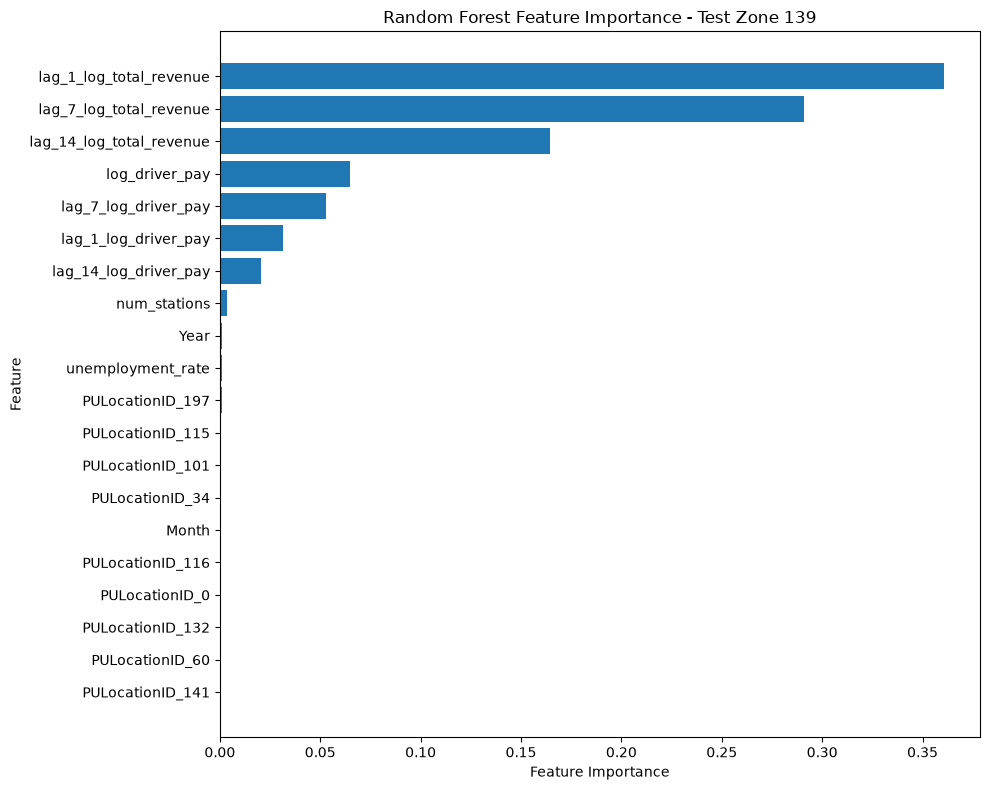

In [45]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# ============================================================
# 1. Set the test zone
# ============================================================

TEST_ZONE = 139   # <-- Change this to whichever PULocationID you want

# ============================================================
# 2. Create a separate DataFrame for modelling
# ============================================================

# Keep data_2 unchanged
model_data = data_2.drop(
    "date",
    "total_revenue",
    "driver_pay"
)

# Remove rows with missing values
model_data = model_data.dropna()

# ============================================================
# 3. Create chronological train/test sets
# ============================================================

# Training data:
# All locations, years 2023-2025
train_data = model_data.filter(
    (F.col("Year") >= 2023) &
    (F.col("Year") <= 2025)
)

# Test data:
# ONLY TEST_ZONE, Year = 2026
test_data = model_data.filter(
    (F.col("Year") == 2026) &
    (F.col("PULocationID") == TEST_ZONE)
)

print("========================================")
print(f"TEST_ZONE: {TEST_ZONE}")
print("========================================")
print(f"Training rows: {train_data.count()}")
print(f"Test rows:     {test_data.count()}")

# Check that test set contains exactly one zone
test_data.select("PULocationID").distinct().show()

# ============================================================
# 4. Prepare PULocationID for one-hot encoding
# ============================================================

# Convert PULocationID to string because it is categorical
train_data = train_data.withColumn(
    "PULocationID_str",
    F.col("PULocationID").cast("string")
)

test_data = test_data.withColumn(
    "PULocationID_str",
    F.col("PULocationID").cast("string")
)

# ============================================================
# 5. Index and one-hot encode PULocationID
# ============================================================

location_indexer = StringIndexer(
    inputCol="PULocationID_str",
    outputCol="PULocationID_index",
    handleInvalid="keep"
)

location_encoder = OneHotEncoder(
    inputCol="PULocationID_index",
    outputCol="PULocationID_encoded"
)

# ============================================================
# 6. Define the remaining model features
# ============================================================

target = "log_total_revenue"

feature_cols = [
    "lag_1_log_total_revenue",
    "lag_7_log_total_revenue",
    "lag_14_log_total_revenue",
    "log_driver_pay",
    "lag_1_log_driver_pay",
    "lag_7_log_driver_pay",
    "lag_14_log_driver_pay",
    "num_stations",
    "Year",
    "Month",
    "unemployment_rate"
]

# ============================================================
# 7. Assemble all features
# ============================================================

assembler = VectorAssembler(
    inputCols=feature_cols + ["PULocationID_encoded"],
    outputCol="features"
)

# ============================================================
# 8. Create Random Forest
# ============================================================

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target,
    numTrees=100,
    maxDepth=10,
    seed=42
)

# ============================================================
# 9. Build the pipeline
# ============================================================

pipeline = Pipeline(
    stages=[
        location_indexer,
        location_encoder,
        assembler,
        rf
    ]
)

# ============================================================
# 10. Train the model
# ============================================================

model = pipeline.fit(train_data)

# ============================================================
# 11. Make predictions on the 2026 TEST_ZONE
# ============================================================

predictions = model.transform(test_data)

predictions.select(
    "PULocationID",
    "Year",
    "Month",
    target,
    "prediction"
).show(20)

# ============================================================
# 12. Evaluate model performance
# ============================================================

rmse_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)
r2 = r2_evaluator.evaluate(predictions)

print("\n========================================")
print("Random Forest Model Performance")
print("========================================")
print(f"Test Zone: {TEST_ZONE}")
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"R²:        {r2:.4f}")
print("========================================")

# ============================================================
# 13. Extract feature importances
# ============================================================

# The Random Forest is the final stage of the pipeline
rf_model = model.stages[-1]

importances = rf_model.featureImportances

# The assembler determines the final feature ordering.
# Get the number of one-hot encoded location features.
location_size = (
    model.stages[1]
    .categorySizes[0]
)

# Build feature names corresponding to the VectorAssembler output
feature_names = feature_cols + [
    f"PULocationID_{i}"
    for i in range(location_size)
]

# Pair feature names with importance values
feature_importance = list(
    zip(
        feature_names,
        importances.toArray()
    )
)

# Sort by importance
feature_importance = sorted(
    feature_importance,
    key=lambda x: x[1],
    reverse=True
)

# ============================================================
# 14. Print feature importance
# ============================================================

print("\n========================================")
print("Feature Importance")
print("========================================")

for feature, importance in feature_importance:
    print(f"{feature}: {importance:.6f}")

# ============================================================
# 15. Plot feature importance
# ============================================================

import matplotlib.pyplot as plt

# Plot only the top 20 features to keep the graph readable
top_n = 20

top_features = feature_importance[:top_n]

features = [x[0] for x in top_features]
importance_values = [x[1] for x in top_features]

plt.figure(figsize=(10, 8))

plt.barh(
    features[::-1],
    importance_values[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    f"Random Forest Feature Importance - Test Zone {TEST_ZONE}"
)

plt.tight_layout()
plt.show()